Estudiante: Moscoso Valeria Sandra


Curso de Herramientas Básicas para el Análisis de Datos

## **1.Selección y alcance del dataset**
### 1.1 Descripción del dataset

*  **Título:** Índice de  aprobados,permanencia y sobreedad escuelas Primarias de la provincia de Buenos Aires
*  link de descarga:https://docs.google.com/spreadsheets/d/1uXuMBD8ju75vkUFmcyO70LxNBgjq-EIccxZLkxUyhnc/edit?gid=1499158433#gid=1499158433
* Formato: csv



*Diccionario del dataset: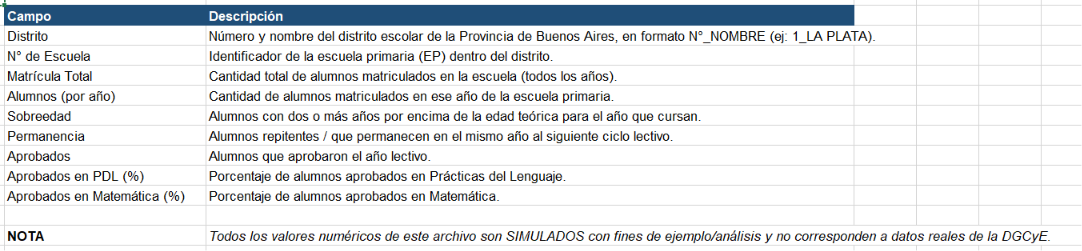





* Cantidad de filas:  842      Cantidad de columnas:29

* 💡 Observaciones: Los datos ingresados son simulaciones, no corresponden a la Dirección General de Cultura y Educación de la provincia de Buenos Aires



## 1.2 Preguntas de investigación

1.¿ En qué año de la trayectoria escolar  se concentra el mayor incremento de sobreedad y  de permanencia?

2.¿Cuál es la relación entre la matrícula total y la cantidad de estudiantes aprobados en Prácticas del Lenguaje y en Matemática?

3.¿En qué área se refleja el mayor porcentaje de aprobados?






# 1.3 Validación de viabilidad


| Pregunta | Columnas necesarias | ¿Están en el dataset? | ¿Viable? (Sí / Reformular) |
|---|---|---|---|
| P1 | Todas las columnas referidas a sobreedad y repitencia de 2° a 6° año | Sí | Sí |
| P2 | Matrícula total , Aprobados en PDL (%), Aprobados en Matemática (%) | Sí | Sí |
| P3 |Aprobados en PDL (%), Aprobados en Matemática (%)  | SÍ | SÍ |


# **2. Carga del dataset**

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import seaborn as sns
import plotly.express as px

print("✅ Librerías importadas correctamente")

""
RUTA_ARCHIVO = "https://docs.google.com/spreadsheets/d/1uXuMBD8ju75vkUFmcyO70LxNBgjq-EIccxZLkxUyhnc/edit?gid=1499158433#gid=1499158433"

✅ Librerías importadas correctamente


In [84]:
data_cruda=pd.read_csv("https://docs.google.com/spreadsheets/d/1uXuMBD8ju75vkUFmcyO70LxNBgjq-EIccxZLkxUyhnc/export?format=csv&gid=1499158433")

In [85]:

print("Dimensiones:", data_cruda.shape)

Dimensiones: (842, 29)


In [86]:

data_cruda.tail(5)

,Distrito,N° de Escuela,Matrícula Total,1° año - Alumnos,1° año - Sobreedad,1° año - Permanencia,1° año - Aprobados,2° año - Alumnos,2° año - Sobreedad,2° año - Permanencia,...,5° año - Alumnos,5° año - Sobreedad,5° año - Permanencia,5° año - Aprobados,6° año - Alumnos,6° año - Sobreedad,6° año - Permanencia,6° año - Aprobados,Aprobados en PDL (%),Aprobados en Matemática (%)
837,136_ITUZAINGO,EP N° 209,238.0,36.0,0.0,0.0,36.0,41.0,2.0,1.0,...,37.0,2.0,1.0,36.0,41.0,2.0,0.0,41.0,98.80%,86.61%
838,137_LEZAMA,EP N° 359,178.0,36.0,0.0,0.0,36.0,22.0,1.0,0.0,...,33.0,3.0,0.0,33.0,30.0,1.0,1.0,29.0,96.91%,96.77%
839,137_LEZAMA,EP N° 446,368.0,60.0,0.0,0.0,60.0,47.0,3.0,2.0,...,71.0,4.0,3.0,68.0,66.0,2.0,3.0,63.0,86.96%,87.21%
840,137_LEZAMA,EP N° 553,299.0,42.0,0.0,0.0,42.0,49.0,4.0,1.0,...,54.0,2.0,2.0,52.0,49.0,5.0,1.0,48.0,94.00%,87.10%
841,NaN,EP N° 678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **3.Preparación de los datos**

# 3.1 Diagnóstico

In [87]:
data_cruda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Distrito                     841 non-null    object 
 1   N° de Escuela                842 non-null    object 
 2   Matrícula Total              841 non-null    float64
 3   1° año - Alumnos             841 non-null    float64
 4   1° año - Sobreedad           841 non-null    float64
 5   1° año - Permanencia         841 non-null    float64
 6   1° año - Aprobados           841 non-null    float64
 7   2° año - Alumnos             841 non-null    float64
 8   2° año - Sobreedad           841 non-null    float64
 9   2° año - Permanencia         841 non-null    float64
 10  2° año - Aprobados           841 non-null    float64
 11  3° año - Alumnos             841 non-null    float64
 12  3° año - Sobreedad           841 non-null    float64
 13  3° año - Permanencia

In [88]:
nulos = data_cruda.isna().sum()
porcentaje_nulos = (data_cruda.isna().mean() * 100).round(1)

resumen_nulos = pd.DataFrame({"nulos": nulos, "porcentaje": porcentaje_nulos})
resumen_nulos[resumen_nulos["nulos"] > 0].sort_values("porcentaje", ascending=False)

,nulos,porcentaje
Distrito,1,0.1
Matrícula Total,1,0.1
1° año - Alumnos,1,0.1
1° año - Sobreedad,1,0.1
1° año - Permanencia,1,0.1
1° año - Aprobados,1,0.1
2° año - Alumnos,1,0.1
2° año - Sobreedad,1,0.1
2° año - Permanencia,1,0.1
2° año - Aprobados,1,0.1


In [89]:
print("Filas duplicadas:", data_cruda.duplicated().sum())


Filas duplicadas: 0


In [90]:
unicos = data_cruda.nunique()
print(unicos.sort_values())

columnas_varianza_nula = unicos[unicos <= 1].index.tolist()
print("\nColumnas con varianza nula:", columnas_varianza_nula)

1° año - Permanencia             1
1° año - Sobreedad               1
3° año - Permanencia             8
2° año - Permanencia             8
4° año - Permanencia             8
5° año - Permanencia             9
6° año - Permanencia            10
2° año - Sobreedad              11
4° año - Sobreedad              11
3° año - Sobreedad              12
5° año - Sobreedad              12
6° año - Sobreedad              12
N° de Escuela                   29
3° año - Aprobados              92
3° año - Alumnos                95
2° año - Aprobados              95
5° año - Aprobados              95
5° año - Alumnos                96
4° año - Aprobados              97
4° año - Alumnos                97
1° año - Alumnos                98
6° año - Aprobados              98
1° año - Aprobados              98
2° año - Alumnos               100
6° año - Alumnos               100
Distrito                       137
Matrícula Total                379
Aprobados en PDL (%)           612
Aprobados en Matemát

In [91]:

data_cruda.describe()

,Matrícula Total,1° año - Alumnos,1° año - Sobreedad,1° año - Permanencia,1° año - Aprobados,2° año - Alumnos,2° año - Sobreedad,2° año - Permanencia,2° año - Aprobados,3° año - Alumnos,...,4° año - Permanencia,4° año - Aprobados,5° año - Alumnos,5° año - Sobreedad,5° año - Permanencia,5° año - Aprobados,6° año - Alumnos,6° año - Sobreedad,6° año - Permanencia,6° año - Aprobados
count,841.000000,841.000000,841.0,841.0,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,267.260404,44.410226,0.0,0.0,44.410226,44.428062,2.736029,1.368609,43.059453,44.575505,...,1.417360,43.131986,44.583829,2.639715,1.292509,43.291320,44.713436,2.625446,1.404281,43.309156
std,116.741778,20.204652,0.0,0.0,20.204652,20.240692,1.983683,1.276962,19.655274,20.261019,...,1.320402,19.531487,20.033078,1.967544,1.271502,19.502736,20.348743,1.912059,1.373449,19.746115
min,14.000000,2.000000,0.0,0.0,2.000000,2.000000,0.000000,0.000000,2.000000,2.000000,...,0.000000,2.000000,2.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,1.000000
25%,187.000000,31.000000,0.0,0.0,31.000000,30.000000,1.000000,0.000000,29.000000,30.000000,...,0.000000,30.000000,31.000000,1.000000,0.000000,30.000000,31.000000,1.000000,0.000000,29.000000
50%,267.000000,43.000000,0.0,0.0,43.000000,44.000000,2.000000,1.000000,43.000000,45.000000,...,1.000000,43.000000,44.000000,2.000000,1.000000,43.000000,44.000000,2.000000,1.000000,42.000000
75%,346.000000,57.000000,0.0,0.0,57.000000,57.000000,4.000000,2.000000,56.000000,59.000000,...,2.000000,56.000000,57.000000,4.000000,2.000000,56.000000,58.000000,4.000000,2.000000,57.000000
max,642.000000,126.000000,0.0,0.0,126.000000,118.000000,10.000000,7.000000,114.000000,110.000000,...,7.000000,105.000000,124.000000,12.000000,8.000000,123.000000,118.000000,11.000000,9.000000,115.000000


In [92]:
col = "Aprobados en PDL (%)"

data_cruda[col] = data_cruda[col].astype(str).str.replace('%', '', regex=False).astype(float)

q1 = data_cruda[col].quantile(0.25)
q3 = data_cruda[col].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers = data_cruda[(data_cruda[col] < limite_inf) | (data_cruda[col] > limite_sup)]
print(f"Rango esperado: [{limite_inf:.2f}, {limite_sup:.2f}]")
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(data_cruda)*100:.1f}%)")
outliers.head()

Rango esperado: [77.85, 105.93]
Outliers detectados: 0 (0.0%)


,Distrito,N° de Escuela,Matrícula Total,1° año - Alumnos,1° año - Sobreedad,1° año - Permanencia,1° año - Aprobados,2° año - Alumnos,2° año - Sobreedad,2° año - Permanencia,...,5° año - Alumnos,5° año - Sobreedad,5° año - Permanencia,5° año - Aprobados,6° año - Alumnos,6° año - Sobreedad,6° año - Permanencia,6° año - Aprobados,Aprobados en PDL (%),Aprobados en Matemática (%)


In [93]:
col = "Aprobados en Matemática (%)"


data_cruda[col] = data_cruda[col].astype(str).str.replace('%', '', regex=False).astype(float)

q1 = data_cruda[col].quantile(0.25)
q3 = data_cruda[col].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers = data_cruda[(data_cruda[col] < limite_inf) | (data_cruda[col] > limite_sup)]
print(f"Rango esperado: [{limite_inf:.2f}, {limite_sup:.2f}]")
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(data_cruda)*100:.1f}%)")
outliers.head()

Rango esperado: [71.31, 106.48]
Outliers detectados: 0 (0.0%)


,Distrito,N° de Escuela,Matrícula Total,1° año - Alumnos,1° año - Sobreedad,1° año - Permanencia,1° año - Aprobados,2° año - Alumnos,2° año - Sobreedad,2° año - Permanencia,...,5° año - Alumnos,5° año - Sobreedad,5° año - Permanencia,5° año - Aprobados,6° año - Alumnos,6° año - Sobreedad,6° año - Permanencia,6° año - Aprobados,Aprobados en PDL (%),Aprobados en Matemática (%)


# **3.2 Limpieza**

In [94]:
data_set_limpio = data_cruda.copy()
data_set_limpio.dropna(inplace=True)

Se ejecuta el data_cruda.copy para no modificar el original.
Habiéndose observado datos nulos se ejecuta data_set_limpio.dropna(inplace=True) para que los cambios se guarden

In [95]:
data_set_limpio.isna().sum()

,0
Distrito,0
N° de Escuela,0
Matrícula Total,0
1° año - Alumnos,0
1° año - Sobreedad,0
1° año - Permanencia,0
1° año - Aprobados,0
2° año - Alumnos,0
2° año - Sobreedad,0
2° año - Permanencia,0


Luego se ejecutar  df.dropna()  todas las columnas muestran un 0, lo que significa que actualmente no hay valores nulos en el DataFrame df.

# **4.Análisis de datos (EDA)**

## **. Respuestas a Preguntas de Investigación**



### **Pregunta 1: ¿En qué año de la trayectoria escolar se concentra el mayor incremento de sobreedad y permanencia?**

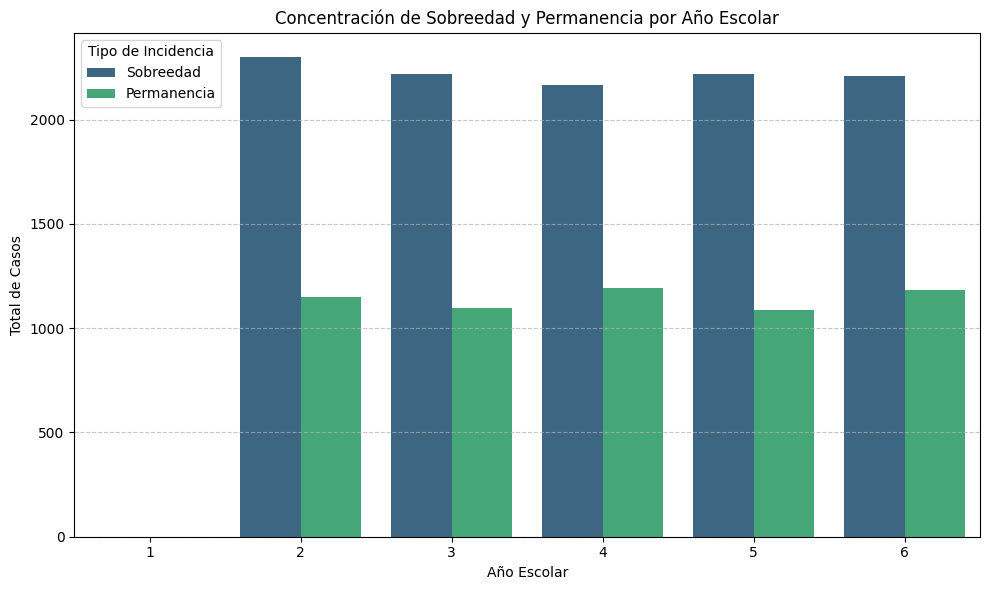

In [96]:


sobreedad_cols = [col for col in data_set_limpio.columns if 'Sobreedad' in col and 'año' in col]
permanencia_cols = [col for col in data_set_limpio.columns if 'Permanencia' in col and 'año' in col]


sobreedad_por_ano = data_set_limpio[sobreedad_cols].sum()
permanencia_por_ano = data_set_limpio[permanencia_cols].sum()

#
sobreedad_por_ano.index = [int(col.split('°')[0]) for col in sobreedad_por_ano.index]
permanencia_por_ano.index = [int(col.split('°')[0]) for col in permanencia_por_ano.index]

df_plot = pd.DataFrame({
    'Sobreedad': sobreedad_por_ano,
    'Permanencia': permanencia_por_ano
})
df_plot.index.name = 'Año Escolar'
df_plot = df_plot.reset_index()

df_plot_melted = df_plot.melt(id_vars='Año Escolar', var_name='Tipo de Incidencia', value_name='Total de Casos')


plt.figure(figsize=(10, 6))
sns.barplot(x='Año Escolar', y='Total de Casos', hue='Tipo de Incidencia', data=df_plot_melted, palette='viridis')
plt.title('Concentración de Sobreedad y Permanencia por Año Escolar')
plt.xlabel('Año Escolar')
plt.ylabel('Total de Casos')
plt.xticks(rotation=0)
plt.legend(title='Tipo de Incidencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

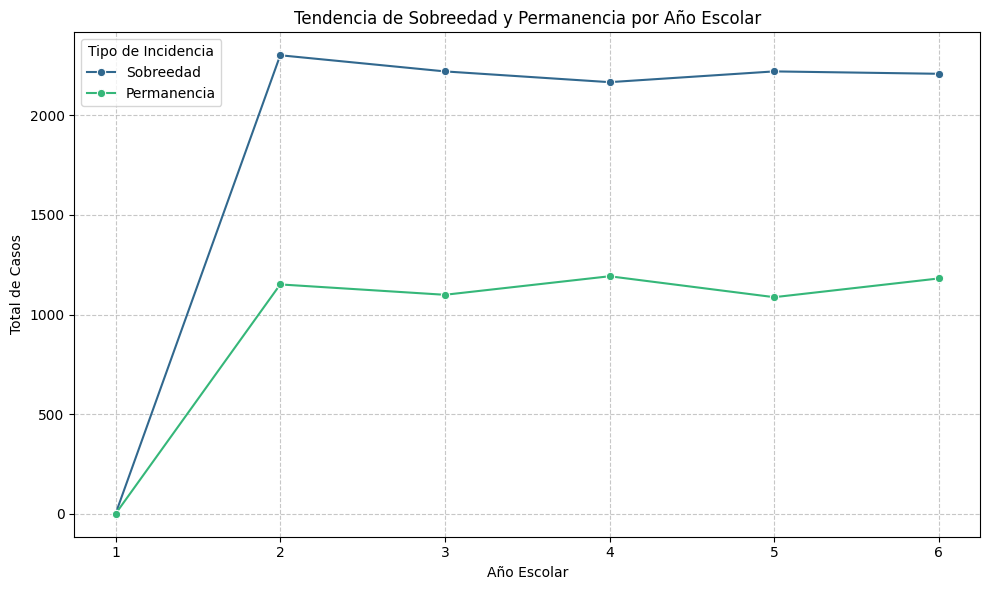

In [97]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Año Escolar', y='Total de Casos', hue='Tipo de Incidencia', data=df_plot_melted, marker='o', palette='viridis')
plt.title('Tendencia de Sobreedad y Permanencia por Año Escolar')
plt.xlabel('Año Escolar')
plt.ylabel('Total de Casos')
plt.xticks(df_plot_melted['Año Escolar'].unique())
plt.legend(title='Tipo de Incidencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Pregunta 2. ¿Cuál es la relación entre la matrícula total y la cantidad de estudiantes aprobados en Prácticas del Lenguaje y en Matemática?**



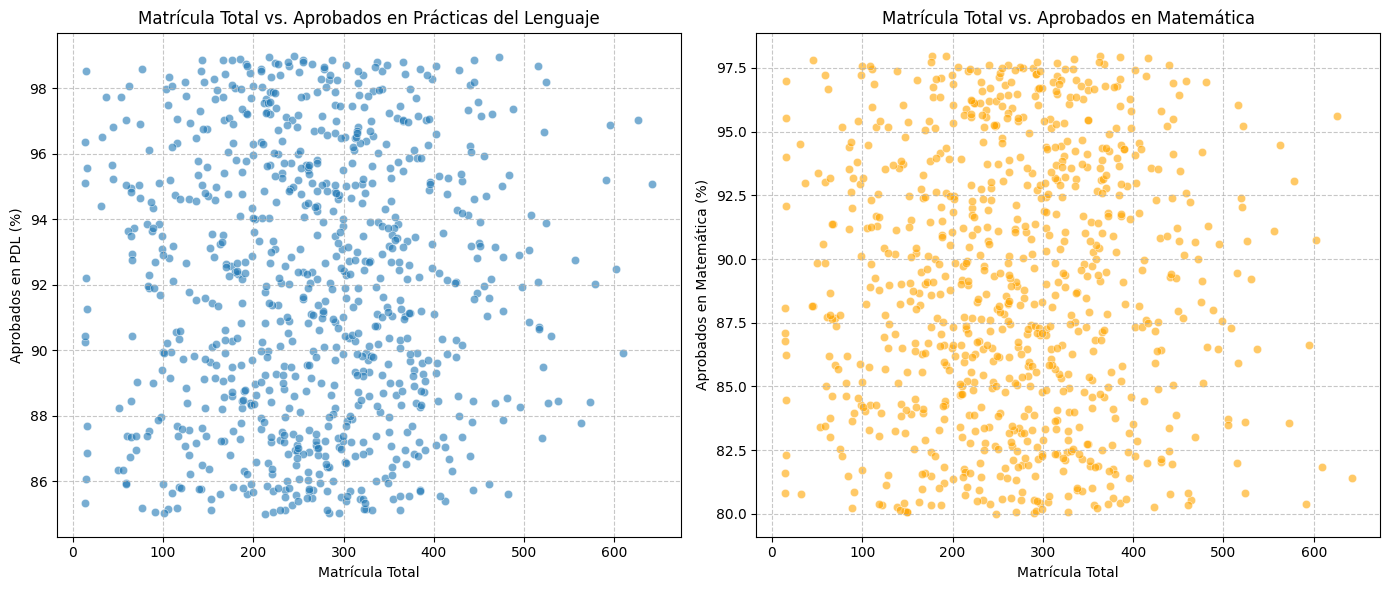

In [98]:
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.scatterplot(x='Matrícula Total', y='Aprobados en PDL (%)', data=data_set_limpio, alpha=0.6)
plt.title('Matrícula Total vs. Aprobados en Prácticas del Lenguaje')
plt.xlabel('Matrícula Total')
plt.ylabel('Aprobados en PDL (%)')
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
sns.scatterplot(x='Matrícula Total', y='Aprobados en Matemática (%)', data=data_set_limpio, alpha=0.6, color='orange')
plt.title('Matrícula Total vs. Aprobados en Matemática')
plt.xlabel('Matrícula Total')
plt.ylabel('Aprobados en Matemática (%)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [99]:
correlation_pdl = data_set_limpio['Matrícula Total'].corr(data_set_limpio['Aprobados en PDL (%)'])
correlation_matematica = data_set_limpio['Matrícula Total'].corr(data_set_limpio['Aprobados en Matemática (%)'])

print(f"Correlación Pearson (Matrícula Total vs. Aprobados en PDL %): {correlation_pdl:.2f}")
print(f"Correlación Pearson (Matrícula Total vs. Aprobados en Matemática %): {correlation_matematica:.2f}")

Correlación Pearson (Matrícula Total vs. Aprobados en PDL %): 0.02
Correlación Pearson (Matrícula Total vs. Aprobados en Matemática %): 0.02


# **Pregunta 3.¿En qué área se refleja el mayor porcentaje de aprobados?**

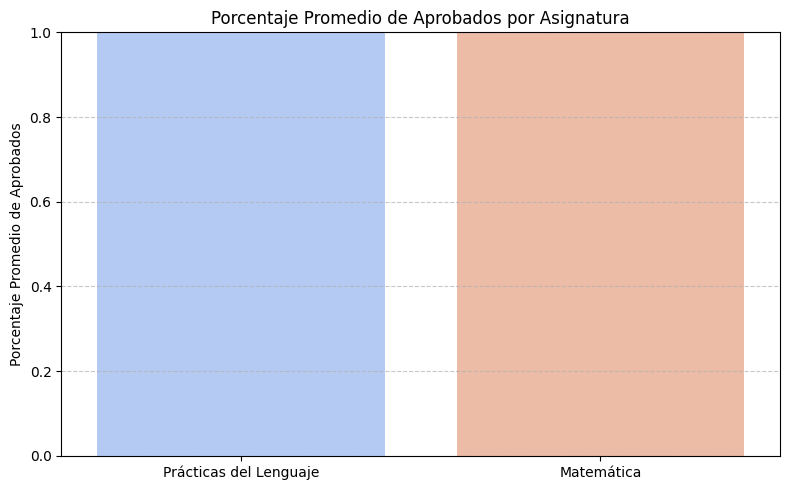

In [79]:
pdl_promedio = data_set_limpio['Aprobados en PDL (%)'].mean()
matematica_promedio = data_set_limpio['Aprobados en Matemática (%)'].mean()

df_aprobados_promedio = pd.DataFrame({
    'Asignatura': ['Prácticas del Lenguaje', 'Matemática'],
    'Porcentaje Promedio de Aprobados': [pdl_promedio, matematica_promedio]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Asignatura', y='Porcentaje Promedio de Aprobados', hue='Asignatura', data=df_aprobados_promedio, palette='coolwarm', legend=False)
plt.title('Porcentaje Promedio de Aprobados por Asignatura')
plt.ylabel('Porcentaje Promedio de Aprobados')
plt.xlabel('')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [100]:

variable = data_set_limpio["Aprobados en PDL (%)"]

print("Media    :", round(variable.mean(), 2))
print("Mediana  :", round(variable.median(), 2))
print("Desvío   :", round(variable.std(), 2))
print("Mínimo   :", variable.min())
print("Máximo   :", variable.max())
print("IQR      :", round(variable.quantile(0.75) - variable.quantile(0.25), 2))
print("Asimetría:", round(variable.skew(), 2))

Media    : 91.94
Mediana  : 92.02
Desvío   : 4.09
Mínimo   : 85.01
Máximo   : 98.99
IQR      : 7.02
Asimetría: 0.03


In [101]:

variable = data_set_limpio["Aprobados en Matemática (%)"]

print("Media    :", round(variable.mean(), 2))
print("Mediana  :", round(variable.median(), 2))
print("Desvío   :", round(variable.std(), 2))
print("Mínimo   :", variable.min())
print("Máximo   :", variable.max())
print("IQR      :", round(variable.quantile(0.75) - variable.quantile(0.25), 2))
print("Asimetría:", round(variable.skew(), 2))

Media    : 88.91
Mediana  : 88.77
Desvío   : 5.19
Mínimo   : 80.0
Máximo   : 97.98
IQR      : 8.79
Asimetría: 0.04


# **4.2 Síntesis de hallazgo**



2° año muestra el mayor incremento de sobreedad y permanencia con tendencia ascendente.

No se observa que las escuelas con mayor matrícula tiendan a tener consistentemente porcentajes más altos de aprobación. El porcentaje de aprobados parece variar independientemente del tamaño de la matrícula de la escuela.

Prácticas del Lenguaje refleja un porcentaje de aprobados ligeramente mayor en relación a Matemática.



In [102]:
sintesis = """2°año muestra el mayor incremento de sobreedad y permanencia con tendencia ascendente. No se observa que las escuelas con mayor matrícula tiendan a tener consistentemente porcentajes más altos de aprobación . El porcentaje de aprobados parece variar independientemente del tamaño de la matrícula de la escuela. Prácticas del Lenguaje refleja un porcentaje de aprobados ligeramente mayor en relación a Matemática.

""".strip()

print(f"Caracteres: {len(sintesis)} / 500")
assert len(sintesis) <= 500, "⚠️ La síntesis supera los 500 caracteres: recortala."
print("✅ Longitud OK")

Caracteres: 412 / 500
✅ Longitud OK
